In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

## Minisom

In [7]:
df_results=pd.read_csv('csv/resultados_class_minisom.csv')

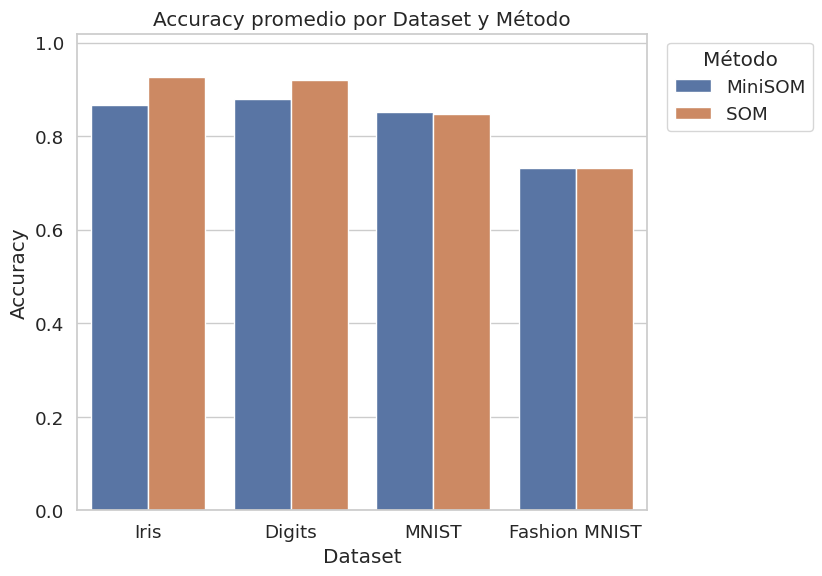

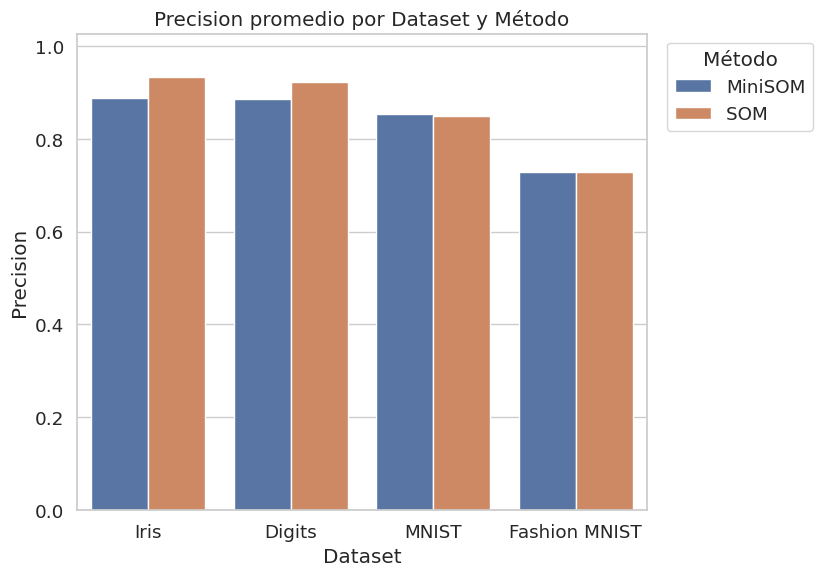

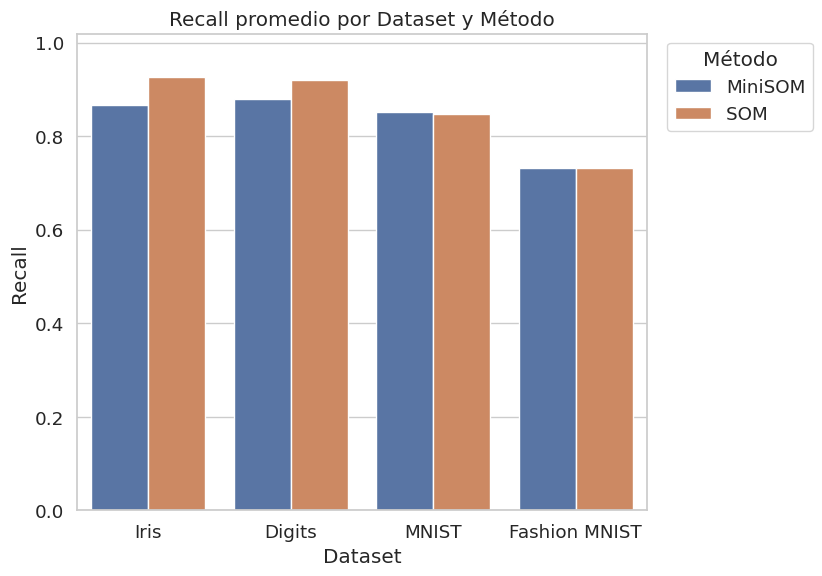

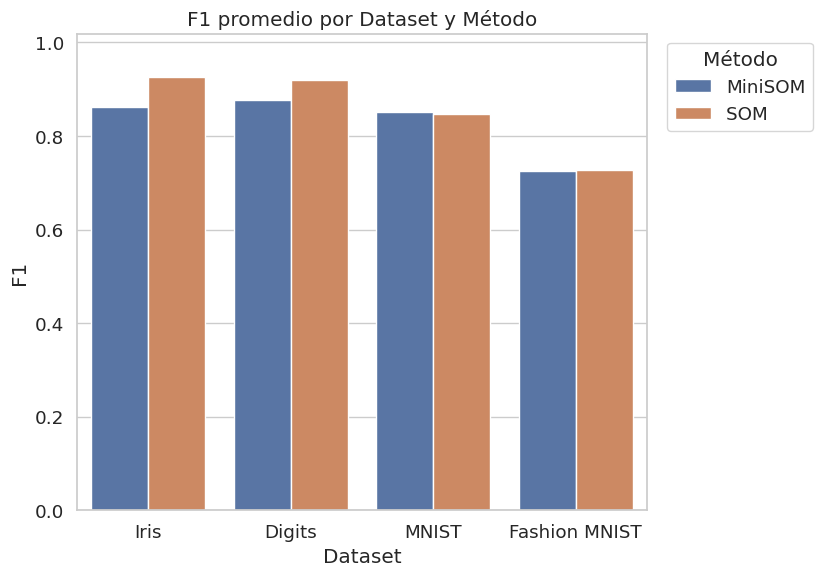

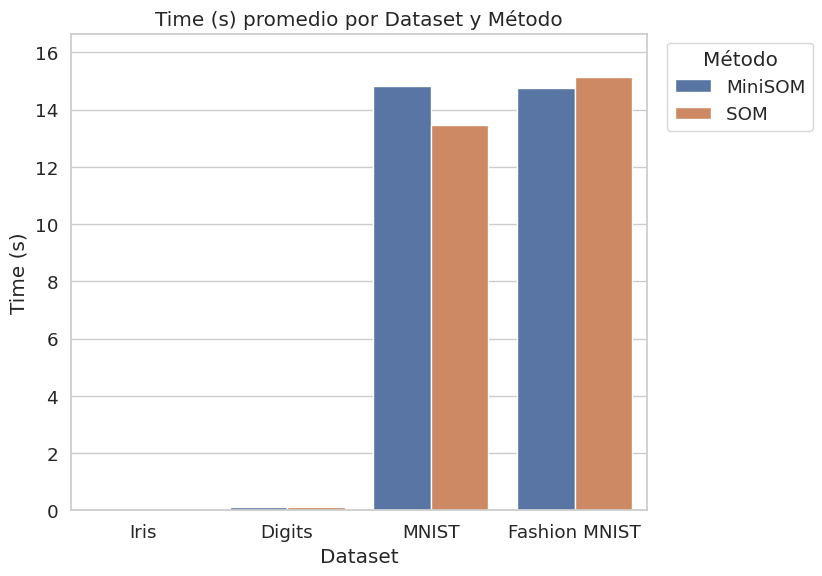

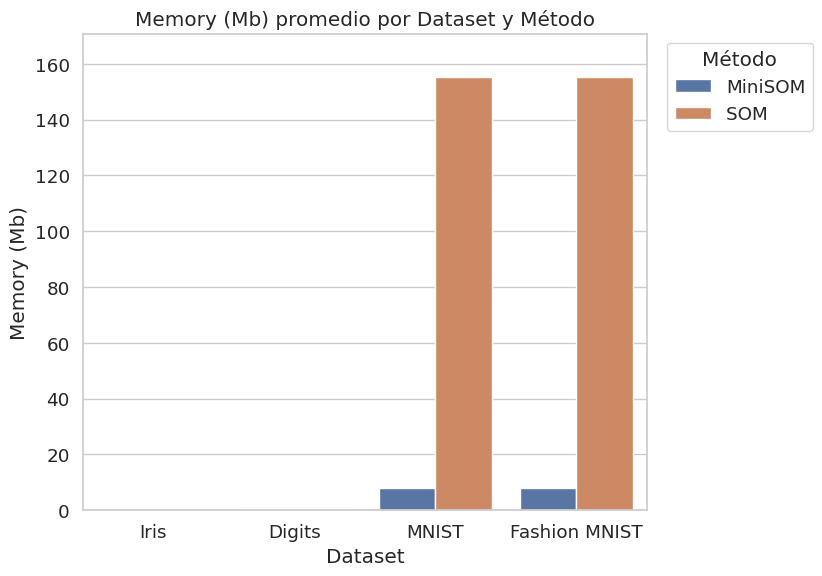

In [11]:
sns.set(style="whitegrid", font_scale=1.2)
sns.set_palette('deep', n_colors=4)
order = ["Iris","Digits","MNIST","Fashion MNIST"]
metrics = ["Accuracy","Precision","Recall","F1","Time (s)","Memory (Mb)"]
for metric in metrics:
    plt.figure(figsize=(10,6))
    ax = sns.barplot(x="Dataset", y=metric, hue="Método", data=df_results, order=order)
    plt.title(f"{metric} promedio por Dataset y Método")
    plt.ylim(0, df_results[metric].max()*1.1)
    plt.legend(title="Método", bbox_to_anchor=(1.02,1), loc='upper left')
    plt.tight_layout(rect=[0,0,0.85,1])
    plt.savefig(f"imgs/minisom/grafico_{metric.lower()}.png")
    plt.show()

## Labeling

In [30]:
df_results=pd.read_csv('csv/results_etiquetado.csv')

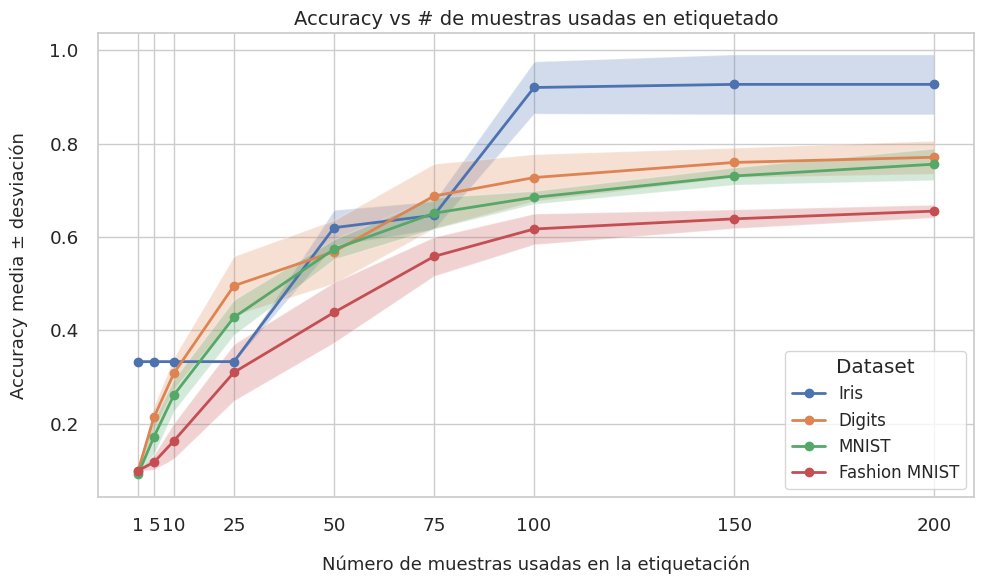

In [ ]:
datasets = ['Iris', 'Digits', 'MNIST', 'Fashion MNIST']

sns.set_style('whitegrid')
sns.set_palette('deep')
plt.rc('font', size=12)
plt.rc('axes', titlesize=14, labelsize=13)
plt.rc('legend', fontsize=12)

fig, ax = plt.subplots(figsize=(10, 6))
fig.subplots_adjust(
    left=0.10,
    right=0.95,
    top=0.90,
    bottom=0.12
)

for ds in datasets:
    data = df_results[df_results['dataset'] == ds]
    mu = data['mean'].values
    sigma = data['std'].values
    s = data['samples'].values

    ax.plot(s, mu, marker='o', linewidth=2, label=ds)
    ax.fill_between(s, mu - sigma, mu + sigma, alpha=0.25)
    # Etiqueta directa al final de la curva
    # ax.text(
    #     s[-1] * 1.02, mu[-1],
    #     ds, va='center', fontsize=12
    # )

ax.set_xscale('linear')
ax.set_xticks(df_results['samples'].unique())
ax.tick_params(axis='x', pad=8)
ax.tick_params(axis='y', pad=8)
ax.xaxis.labelpad = 15
ax.yaxis.labelpad = 15
ax.legend(title='Dataset', loc='lower right')
ax.set_xlabel('Número de muestras usadas en la etiquetación')
ax.set_ylabel('Accuracy media ± desviación')
ax.set_title('Accuracy vs # de muestras usadas en etiquetado')

plt.tight_layout()
plt.savefig("imgs/labeling.png", dpi=300)
plt.show()

### Labeling incremental

In [3]:
df_results=pd.read_csv('csv/results_etiquetado_incremental.csv')

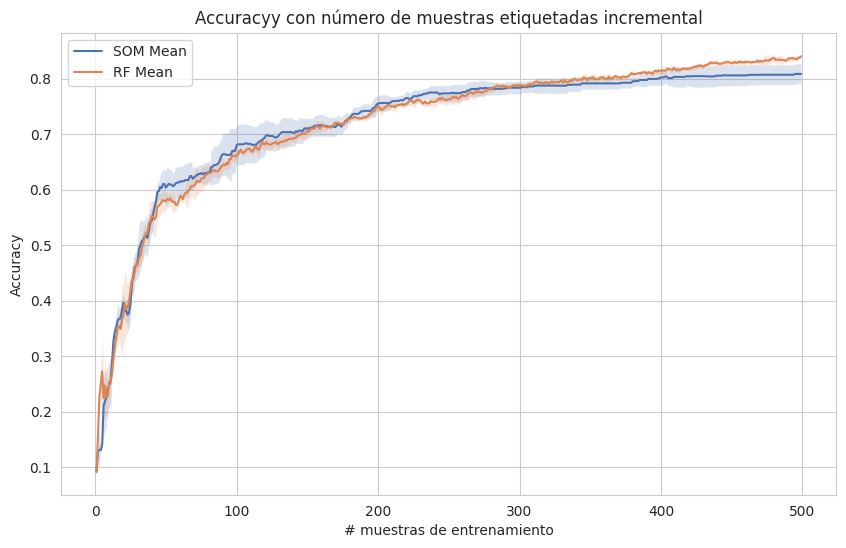

In [8]:
sns.set_style('whitegrid')
sns.set_palette('deep')
plt.figure(figsize=(10,6))
plt.plot(df_results['n'], df_results['SOM_mean'], label='SOM Mean')
plt.fill_between(df_results['n'],
                    df_results['SOM_mean']-df_results['SOM_std'],
                    df_results['SOM_mean']+df_results['SOM_std'],
                    alpha=0.2)
plt.plot(df_results['n'], df_results['RF_mean'], label='RF Mean')
plt.fill_between(df_results['n'],
                    df_results['RF_mean']-df_results['RF_std'],
                    df_results['RF_mean']+df_results['RF_std'],
                    alpha=0.2)
plt.title("Accuracyy con número de muestras etiquetadas incremental")
plt.xlabel("# muestras de entrenamiento")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.savefig("imgs/labeling_incremental.png",dpi=300)
plt.show()

## SUPERVISADO

In [23]:
limitado=False
if limitado:name="results_supervisado_limitado.csv"
else:name="results_supervisado.csv"
df_results=pd.read_csv(f'csv/{name}')

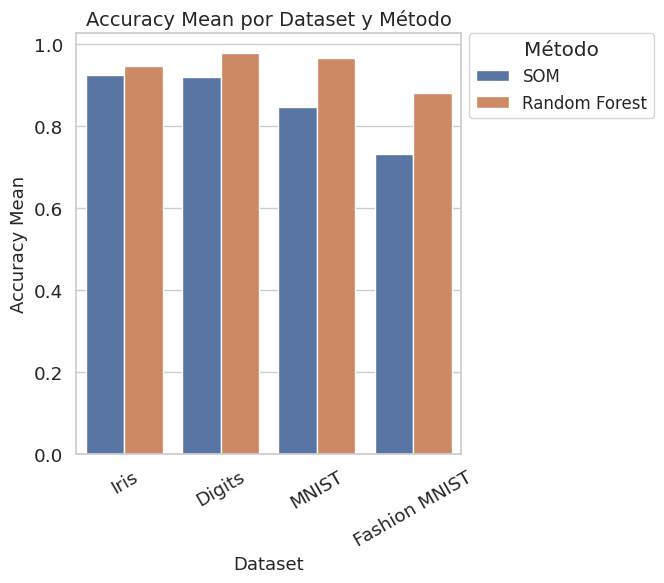

Guardado gráfico accuracy_mean en: imgs/supv/accuracy_mean.png


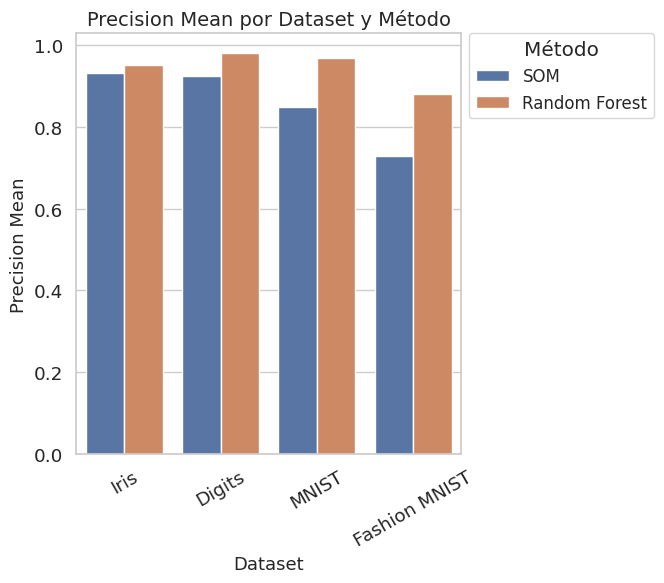

Guardado gráfico precision_mean en: imgs/supv/precision_mean.png


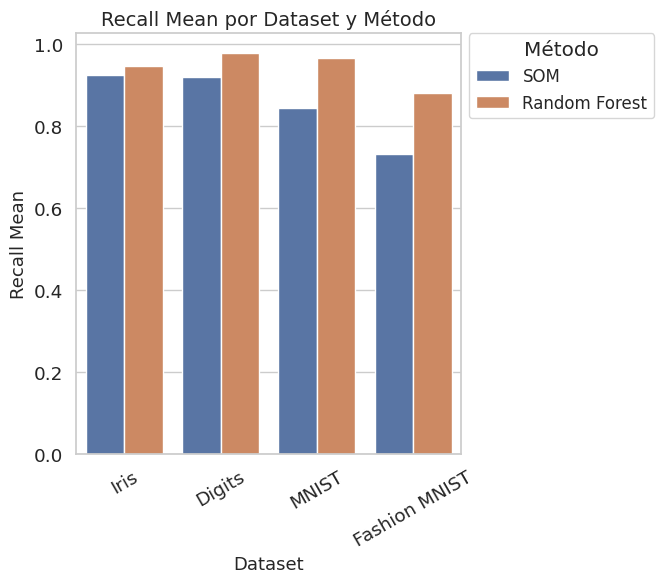

Guardado gráfico recall_mean en: imgs/supv/recall_mean.png


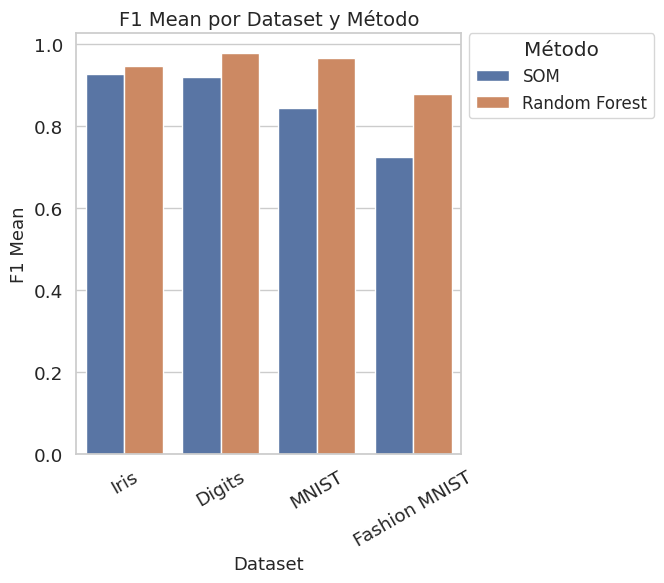

Guardado gráfico f1_mean en: imgs/supv/f1_mean.png


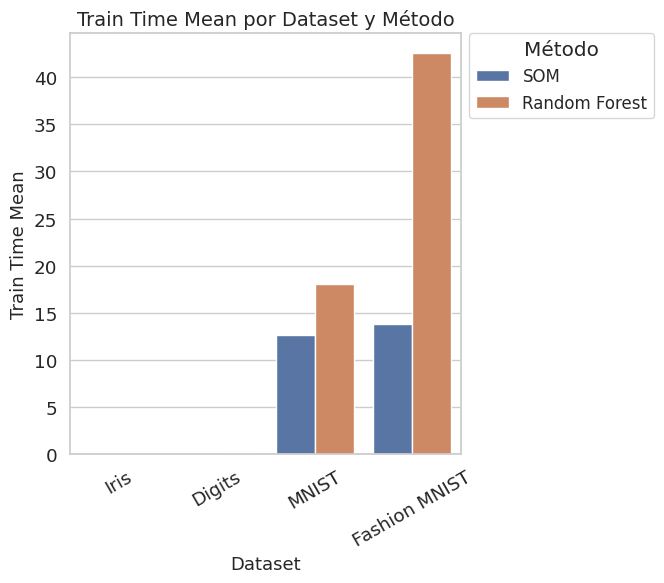

Guardado gráfico train_time_mean en: imgs/supv/train_time_mean.png


In [24]:
output_dir = 'imgs'
os.makedirs(output_dir, exist_ok=True)
# Configurar Seaborn
sns.set_palette('deep')
sns.set_style('whitegrid')

# ------------------------------------------------------------------
# Gráficos de métricas agregadas
# ------------------------------------------------------------------
metrics = ['accuracy_mean', 'precision_mean', 'recall_mean', 'f1_mean', 'train_time_mean']


for metric in metrics:
    plt.figure(figsize=(8, 6))
    ax = sns.barplot(
        x='dataset', 
        y=metric, 
        hue='method', 
        data=df_results
    )
    ax.set_title(f'{metric.replace("_", " ").title()} por Dataset y Método')
    ax.set_xlabel('Dataset')
    ax.set_ylabel(metric.replace('_', ' ').title())
    plt.xticks(rotation=30)
    
    # Sacar la leyenda fuera:
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles, labels,
        loc='upper left',
        bbox_to_anchor=(1.02, 1),
        borderaxespad=0.,
        title='Método'
    )
    
    # Ajustar márgenes para la leyenda
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    
    # Guardar figura
    if limitado:fig_file = f'supv_limitado/{metric}_limitado.png'
    else:fig_file = f'supv/{metric}.png'
    fig_path = os.path.join(output_dir, fig_file)
    plt.tight_layout(rect=[0,0,0.85,1])
    plt.savefig(fig_path, dpi=300)
    plt.show()
    print(f"Guardado gráfico {metric} en: {fig_path}")